In [31]:
import pandas as pd
file=r"C:\Users\sebas\Downloads\titanic.csv"
df=pd.read_csv(file)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [32]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [33]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [34]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [35]:
ds=df[['PassengerId','Survived','Sex']]
ds

,PassengerId,Survived,Sex
0,1,0,male
1,2,1,female
2,3,1,female
3,4,1,female
4,5,0,male
...,...,...,...
886,887,0,male
887,888,1,female
888,889,0,female
889,890,1,male


In [36]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
ds["Sex"]=le.fit_transform(ds["Sex"])
ds.head()

C:\Users\sebas\AppData\Local\Temp\ipykernel_4764\1195710393.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds["Sex"]=le.fit_transform(ds["Sex"])


,PassengerId,Survived,Sex
0,1,0,1
1,2,1,0
2,3,1,0
3,4,1,0
4,5,0,1


In [37]:
X = ds.drop("Sex", axis=1)
y = ds["Sex"]

In [38]:
X


,PassengerId,Survived
0,1,0
1,2,1
2,3,1
3,4,1
4,5,0
...,...,...
886,887,0
887,888,1
888,889,0
889,890,1


In [39]:
y

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int64

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [41]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [42]:
from sklearn.metrics import accuracy_score,classification_report
y_pred_log=log_reg.predict(X_test)
print("logisticRegression")
print("Accuracy:",accuracy_score(y_test,y_pred_log))
print("classification report:",classification_report(y_test,y_pred_log))

logisticRegression
Accuracy: 0.7910447761194029
classification report:               precision    recall  f1-score   support

           0       0.70      0.77      0.74       101
           1       0.85      0.80      0.83       167

    accuracy                           0.79       268
   macro avg       0.78      0.79      0.78       268
weighted avg       0.80      0.79      0.79       268



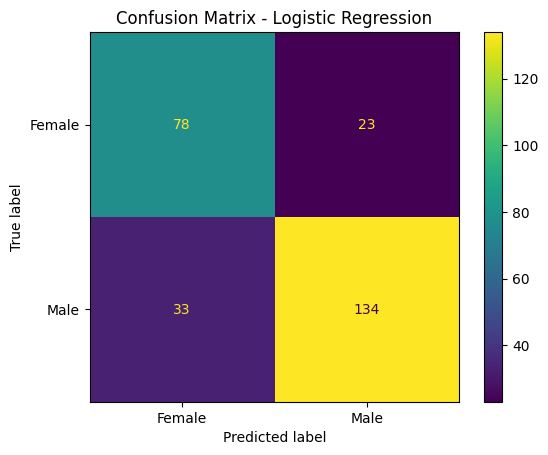

In [43]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred_log)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Female","Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [45]:
new_data=[[830,0]]
new_data_df=pd.DataFrame(new_data,columns=X.columns)
log_result=log_reg.predict(new_data_df)[0]
print("Logistic Regression:",le.inverse_transform([log_result])[0])

Logistic Regression: male
